In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import Voronoi, voronoi_plot_2d
from shapely.geometry import Polygon, Point
import geopandas as gpd
from geopy.distance import geodesic

# Generate realistic latitude and longitude points (e.g., around Berlin)
num_areas = 100
np.random.seed(0)
latitudes = np.random.uniform(52.3, 52.6, num_areas)
longitudes = np.random.uniform(13.2, 13.6, num_areas)
points = np.column_stack((longitudes, latitudes))  # x=lon, y=lat
print(points)
# Convert to Cartesian for Voronoi
vor = Voronoi(points)

# Create bounding box to clip infinite Voronoi regions
bbox = Polygon([(13.15, 52.25), (13.65, 52.25), (13.65, 52.65), (13.15, 52.65)])

# Create Voronoi polygons and clip to bbox
regions = []
centroids = []
for region_idx in vor.point_region:
    region = vor.regions[region_idx]
    if not -1 in region and len(region) > 0:
        poly_points = [vor.vertices[i] for i in region]
        poly = Polygon(poly_points)
        poly = poly.intersection(bbox)
        if poly.area > 0:
            regions.append(poly)
            centroids.append(poly.centroid.coords[0])

# Compute distance matrix between centroids
n = len(centroids)
distance_matrix = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        distance_matrix[i, j] = geodesic((centroids[i][1], centroids[i][0]), (centroids[j][1], centroids[j][0])).km
print(distance_matrix)
# Generate users in each region
users_per_area = 5
user_points = []
for region in regions:
    minx, miny, maxx, maxy = region.bounds
    count = 0
    while count < users_per_area:
        x = np.random.uniform(minx, maxx)
        y = np.random.uniform(miny, maxy)
        if region.contains(Point(x, y)):
            user_points.append((x, y))
            count += 1

# voronoi_plot_2d(vor)

# # Plotting
# from mpl_toolkits.mplot3d import Axes3D

# # Assign synthetic altitudes to centroids (e.g., 100m ± 20m)
# altitudes = np.random.uniform(80, 120, len(centroids))

# # 3D Plotting
# fig = plt.figure(figsize=(12, 10))
# ax = fig.add_subplot(111, projection='3d')

# # Plot Voronoi region edges in 3D at z=0
# for poly in regions:
#     x, y = poly.exterior.xy
#     z = np.zeros_like(x)
#     ax.plot(x, y, z, color='gray', alpha=0.5)

# # Plot centroids with altitude
# for i, (lon, lat) in enumerate(centroids):
#     ax.scatter(lon, lat, altitudes[i], c='red', marker='x', s=50)
#     ax.text(lon, lat, altitudes[i] + 5, f'A{i}', color='black')

# # Plot user points at ground level (z=0)
# for (x, y) in user_points:
#     ax.scatter(x, y, 0, c='green', s=10)

# # Plot drone paths between centroids
# for i in range(len(centroids)):
#     for j in range(i+1, len(centroids)):
#         x_vals = [centroids[i][0], centroids[j][0]]
#         y_vals = [centroids[i][1], centroids[j][1]]
#         z_vals = [altitudes[i], altitudes[j]]
#         ax.plot(x_vals, y_vals, z_vals, 'blue', alpha=0.3)

# # Axis labels
# ax.set_xlabel('Longitude')
# ax.set_ylabel('Latitude')
# ax.set_zlabel('Altitude (m)')
# ax.set_title('3D Voronoi Areas with Drone Paths and Users')
# plt.tight_layout()
# plt.show()

fig, ax = plt.subplots(figsize=(10, 10))
for poly in regions:
    x, y = poly.exterior.xy
    ax.fill(x, y, alpha=0.4, edgecolor='black')

ax.scatter(*zip(*centroids), c='red', marker='x', label='Centroids')
ax.scatter(*zip(*points), c='blue', marker='o', label='Original Nodes')
ax.scatter(*zip(*user_points), c='green', s=10, label='Users')

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Voronoi Areas with Users")
ax.legend()
plt.grid(True)
plt.show()

# Optional: print distance matrix
print("\nDistance Matrix (km):")
print(np.round(distance_matrix, 2))


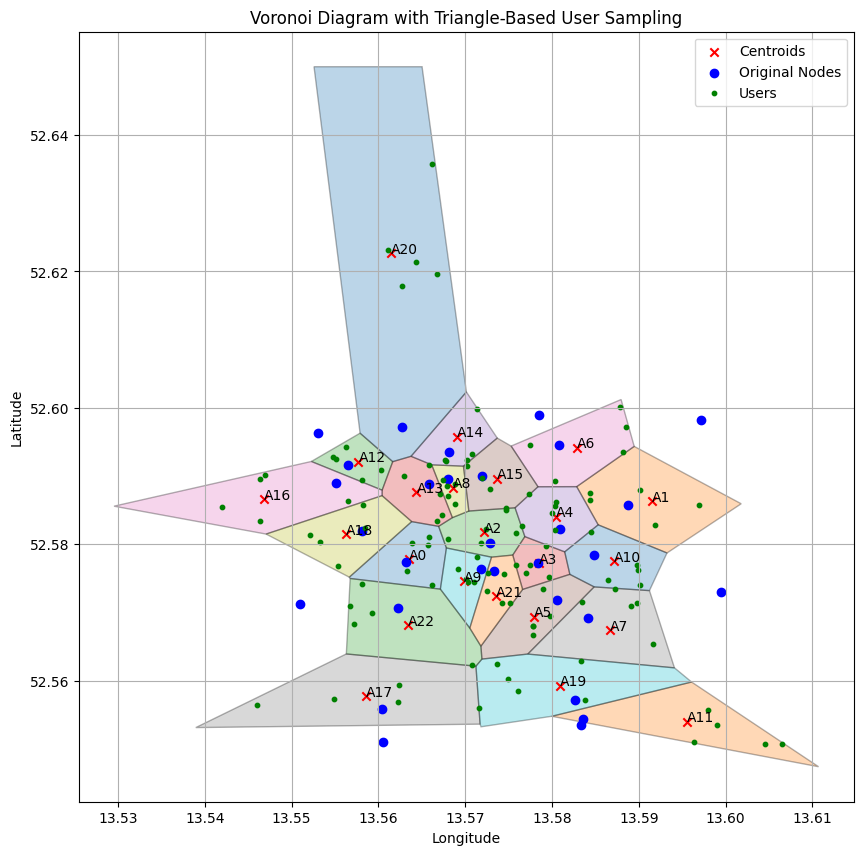

In [1]:
from dummy_app.designs.voronoi_map import MapGenerator 
from dummy_app.models.energy_model import DroneEnergyModel
from dummy_app.models.coverage import * 
from geopy.distance import geodesic

import numpy as np
num_areas = 30
users_per_area = 5 

map_generator = MapGenerator(
    num_areas=num_areas, 
    users_per_area=users_per_area, 
    low_lat=52.55, 
    high_lat=52.6,
    low_long=13.55, 
    high_long=13.6
)

map_generator.generate_points() 
regions, centroids, user_points = map_generator.voronoi_polygons()
distances = map_generator.calculate_centroid_distance(centroids)
# Optional: print distance matrix

# print("\nDistance Matrix (km):")
# print(np.round(distances, 2))
all_user_points = [point for points in user_points.values() for point in points]

map_generator.plot_map(regions, centroids, all_user_points)
# map_generator.plot_map_3D(regions, centroids, user_points)

depots = map_generator.get_central_depots(centroids=centroids)


In [7]:
agent_position = centroids[10]
agent_position

(13.587145018662696, 52.577560904033184)

In [2]:
from collections import defaultdict 

R = defaultdict(list) 
sinr = defaultdict(list) 

altitude = 1250/1e3 
user_height = 1.5/1e3 

terrain_type = "urban" 
agent_position = centroids[10]

for user in user_points[10]: 
    horizontal_distance = geodesic(agent_position, user).km  # in km
    height_difference = altitude - user_height  # in km
    dist = np.sqrt(horizontal_distance**2 + height_difference**2)
    r_value, sinr_value = coverage_u2c(
        agent_to_user_dist=dist, 
        agent_altitude=altitude, 
        user_altitude=user_height, 
        agent_pos=agent_position,
        terrain_type=terrain_type
    )
    R[10].append(r_value)
    sinr[10].append(sinr_value)


2025-05-26 10:55:52 | INFO | lstm_forecaster | Pathloss = 119.53180147395241
2025-05-26 10:55:52 | INFO | lstm_forecaster | Pathloss = 119.70359563878775
2025-05-26 10:55:52 | INFO | lstm_forecaster | Pathloss = 118.68358836439413
2025-05-26 10:55:52 | INFO | lstm_forecaster | Pathloss = 118.82837007431708
2025-05-26 10:55:52 | INFO | lstm_forecaster | Pathloss = 118.70297799097492


In [7]:
print(f"R: {np.mean(R[10])/1e6} Mbps, SINR: {np.mean(sinr[10])} dB")


R: 83.20691449925859 Mbps, SINR: 0.7819134673858704 dB


sigma_2_dB :  -88.0
sigma_2_W :  1.584893192461111e-12
r :  1.3468043299317713
SINR: ==  0.7027807426542945
R : ==  76789267.9379398
sigma_2_dB :  -88.0
sigma_2_W :  1.584893192461111e-12
r :  1.362548578594617
SINR: ==  0.6755234600803615
R : ==  74461188.67838924
sigma_2_dB :  -88.0
sigma_2_W :  1.584893192461111e-12
r :  1.2844796824404634
SINR: ==  0.8543605045780951
R : ==  89092174.42913012
sigma_2_dB :  -88.0
sigma_2_W :  1.584893192461111e-12
r :  1.2931951238062938
SINR: ==  0.8263480233193007
R : ==  86896170.7093939
sigma_2_dB :  -88.0
sigma_2_W :  1.584893192461111e-12
r :  1.2855981268339158
SINR: ==  0.8505546062973003
R : ==  88795770.74143985


In [ ]:
Area_A = tuple(map_generator.vor_map.points[0]) 
Area_B = tuple(map_generator.vor_map.points[2])

dist = distances[0,2]


In [ ]:
energy_model = DroneEnergyModel() 

energy = 1100 * 3600 
print("Before" , energy)
energy = energy_model.recover_energy(energy)
print(energy)

In [ ]:
energy_model.ascend_energy(current_node=0, next_node=2, altitude=1250, distance_matrix=distances)
energy_model.hover_energy()
energy_model.coverage_energy(1250)
energy_model.descend_energy(current_node=2,next_node=0,altitude=1250,distance_matrix=distances)
energy_matrix = np.ndarray(distances.shape)
for i in range(len(distances)):
    for j in range(len(distances)):
        energy_matrix[i,j] = energy_model.move_energy(current_node=i,next_node=j,distance_matrix=distances)
energy_matrix.mean()